# 1. Librerías y dependencias

In [2]:
!pip install ucimlrepo


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\aleja\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Descarga del Dataset
Se realiza la importación directa desde el repositorio UCI Machine Learning utilizando su identificador oficial (ID: 17).

In [4]:
# Cargar el dataset oficial
breast_cancer = fetch_ucirepo(id=17)

# Separar características (X) y variable objetivo (y)
X_raw = breast_cancer.data.features
y_raw = breast_cancer.data.targets

print("Shape inicial de X (características):", X_raw.shape)
print("Shape inicial de y (objetivo):", y_raw.shape)

Shape inicial de X (características): (569, 30)
Shape inicial de y (objetivo): (569, 1)


# 3. Limpieza y Adecuación de Datos
De acuerdo con las especificaciones del dataset, no existen valores faltantes (nulos). Sin embargo, se realizan las siguientes adecuaciones críticas para garantizar el correcto desempeño de los modelos:
1. **Eliminar la columna ID:** El número de identificación del paciente no aporta información predictiva y puede alterar negativamente modelos basados en distancias como k-NN. (Nota: Al usar `fetch_ucirepo`, la columna ID ya se excluye automáticamente de las características, por lo que confirmamos que `X` contiene únicamente las 30 variables continuas).
2. **Codificar la variable objetivo (Diagnosis):** Se transforman las etiquetas categóricas 'M' (Maligno) y 'B' (Benigno) en valores numéricos binarios `1` y `0` respectivamente, lo cual es indispensable para el cálculo de métricas y funciones de pérdida.

In [5]:
# Copiar las características y verificar que no tengan IDs numéricos irrelevantes
X = X_raw.copy()

# Codificar la variable objetivo (Diagnosis): M -> 1, B -> 0
y = y_raw.copy()
y['Diagnosis'] = y['Diagnosis'].map({'M': 1, 'B': 0})

# Consolidar en un único DataFrame para la fase de Análisis Exploratorio (EDA)
df = pd.concat([X, y], axis=1)

# Verificar la ausencia de valores faltantes en todo el DataFrame
print(f"Valores faltantes totales en el dataset: {df.isnull().sum().sum()}")

Valores faltantes totales en el dataset: 0


# 4. Análisis exploratorio de datos (EDA)
Evaluación de la composición de la base de datos, comportamiento de las variables numéricas y su relación con la clasificación del tumor.


## 4.1. Análisis univariado y bivariado (Distribución y separación de clases)
Dado que todas las variables predictoras son continuas y el objetivo es la clasificación, se integran las perspectivas univariada y bivariada.

### 4.1.1. Variable objetivo
Análisis del balance de las clases dentro del conjunto de datos para la variable `Diagnosis`, representado mediante su distribución absoluta y su proporción porcentual.

In [6]:
# Conteo y porcentaje de la variable objetivo
conteo = df['Diagnosis'].value_counts()
print(f"Benigno (0): {conteo[0]} muestras ({conteo[0] / len(df) * 100:.2f}%)")
print(f"Maligno (1): {conteo[1]} muestras ({conteo[1] / len(df) * 100:.2f}%)")

Benigno (0): 357 muestras (62.74%)
Maligno (1): 212 muestras (37.26%)


Benigno (0): 357 muestras (62.74%)
Maligno (1): 212 muestras (37.26%)


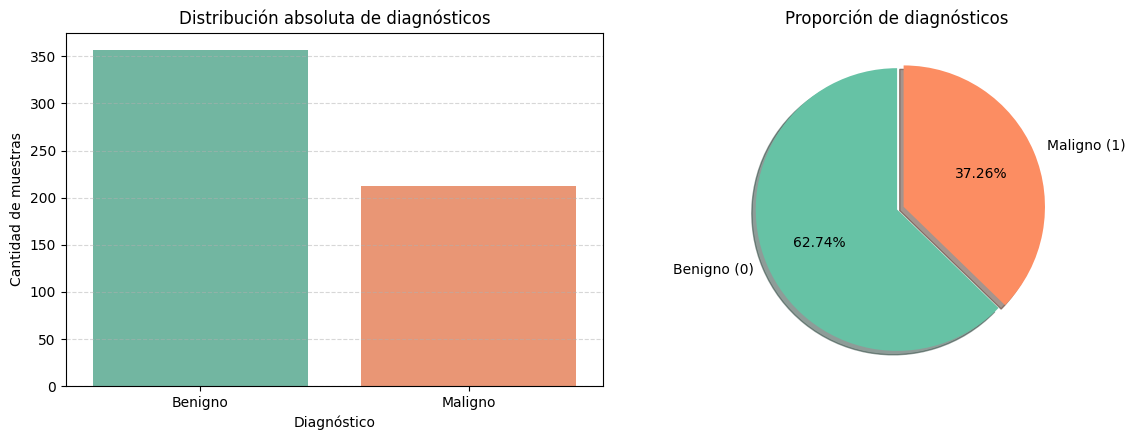

In [7]:
conteo = df['Diagnosis'].value_counts()
print(f"Benigno (0): {conteo[0]} muestras ({conteo[0] / len(df) * 100:.2f}%)")
print(f"Maligno (1): {conteo[1]} muestras ({conteo[1] / len(df) * 100:.2f}%)")

# Crear una figura con 1 fila y 2 columnas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4.5))

# 1. Gráfico de barras (Ahora en la posición 0, izquierda)
sns.countplot(x='Diagnosis', data=df, hue='Diagnosis', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Distribución absoluta de diagnósticos')
axes[0].set_xlabel('Diagnóstico')
axes[0].set_ylabel('Cantidad de muestras')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Benigno', 'Maligno'])
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# 2. Gráfico circular / Pie Chart (Ahora en la posición 1, derecha)
axes[1].pie(conteo, labels=['Benigno (0)', 'Maligno (1)'], autopct='%1.2f%%', 
            colors=sns.color_palette('Set2'), startangle=90, explode=(0, 0.05), shadow=True)
axes[1].set_title('Proporción de diagnósticos')

plt.tight_layout()
plt.show()

### 4.1.2. Características clínicas
Para las 10 características físicas base de los núcleos celulares, se evalúan sus tres métricas calculadas (Promedio, Error Estándar y Peor valor). Por cada una se presenta:
* **Histograma:** Para observar la distribución general de los datos.
* **Boxplot (Separado por Diagnóstico):** Para identificar visualmente el poder discriminativo de la variable (separación entre cajas) y la presencia de valores atípicos. 

*Nota Clínica:* Los valores atípicos identificados en los diagramas de caja no serán eliminados, ya que representan variaciones morfológicas reales de tumores severos y borrarlos restaría capacidad predictiva al modelo.

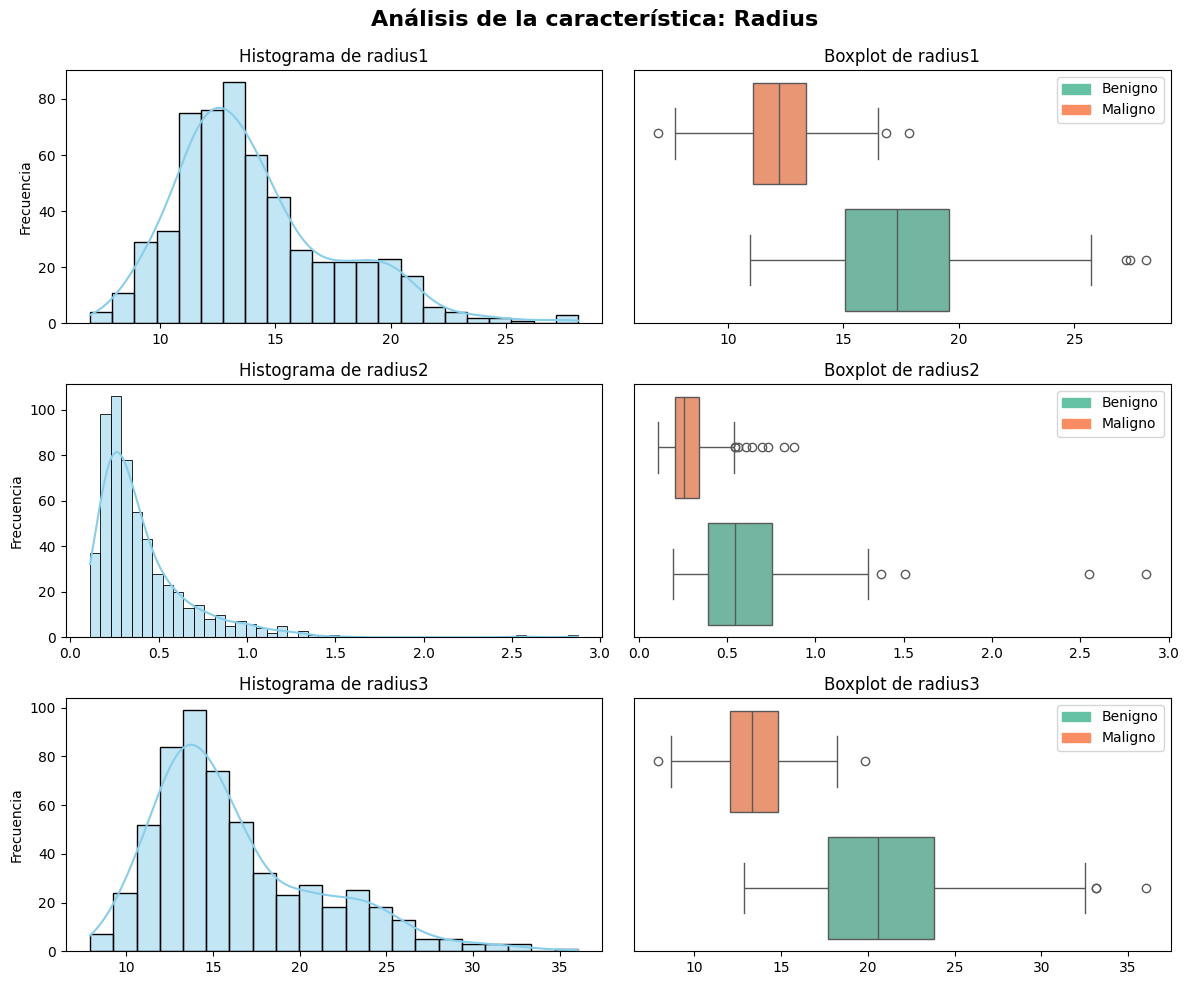

----------------------------------------------------------------------------------------------------


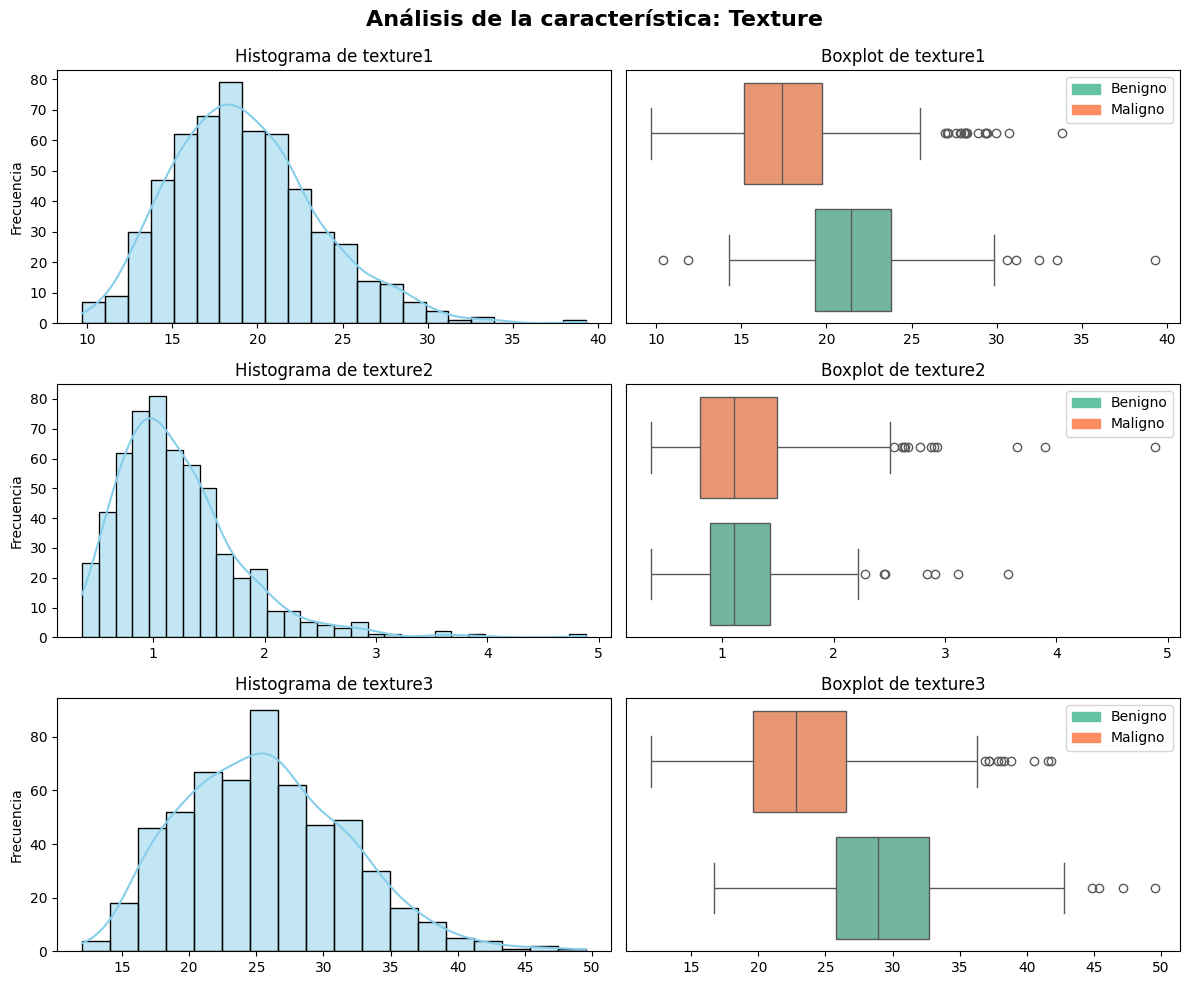

----------------------------------------------------------------------------------------------------


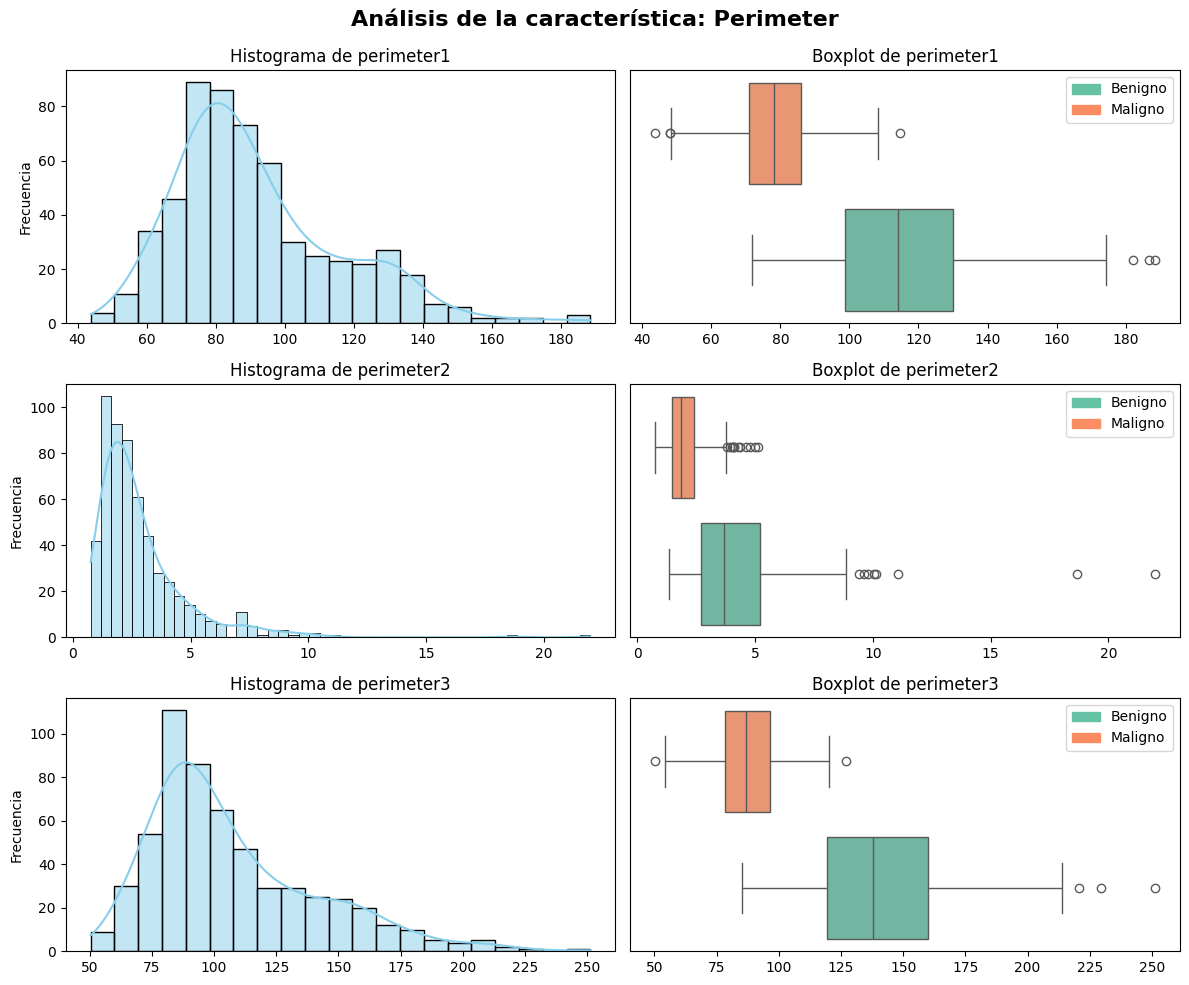

----------------------------------------------------------------------------------------------------


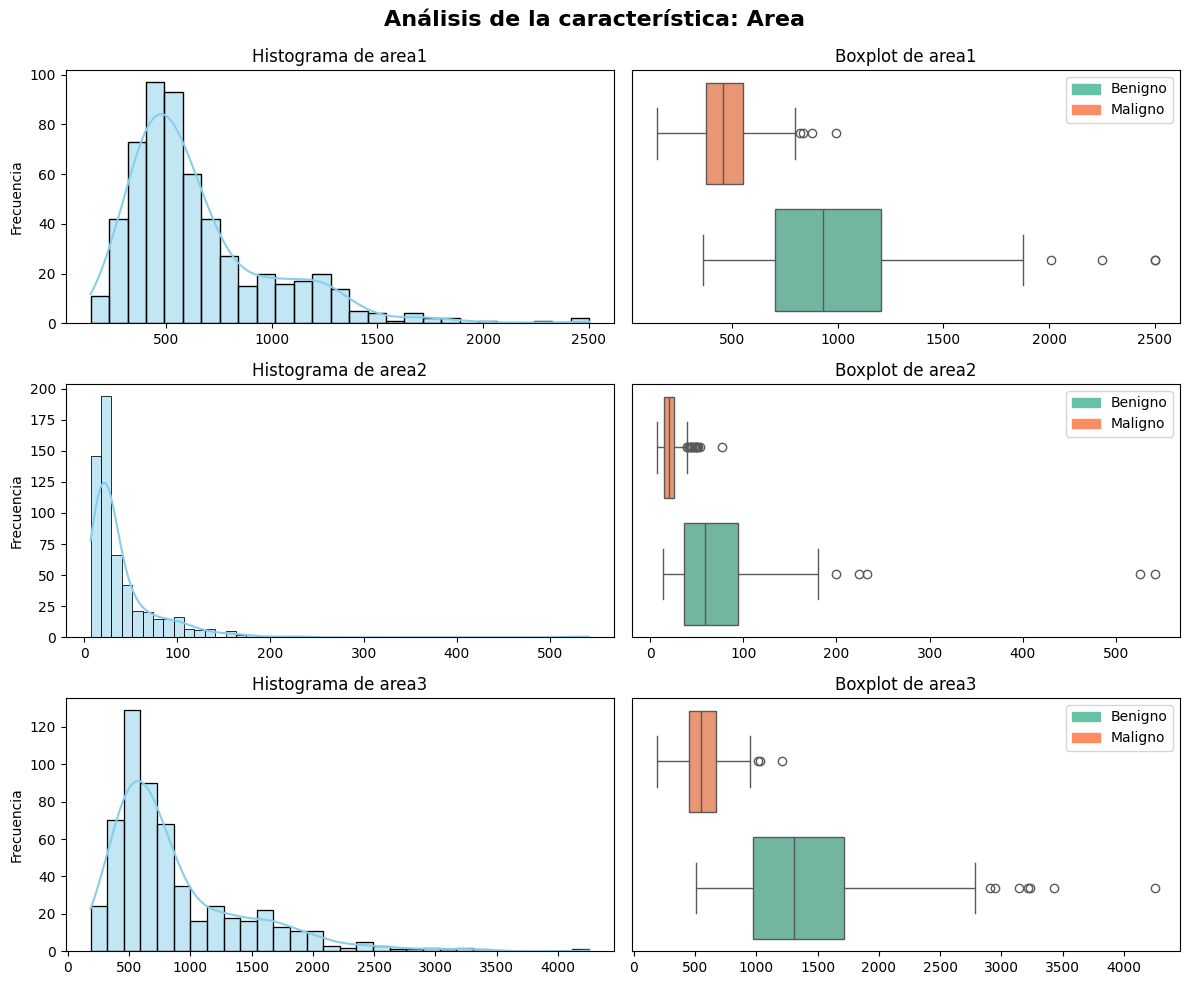

----------------------------------------------------------------------------------------------------


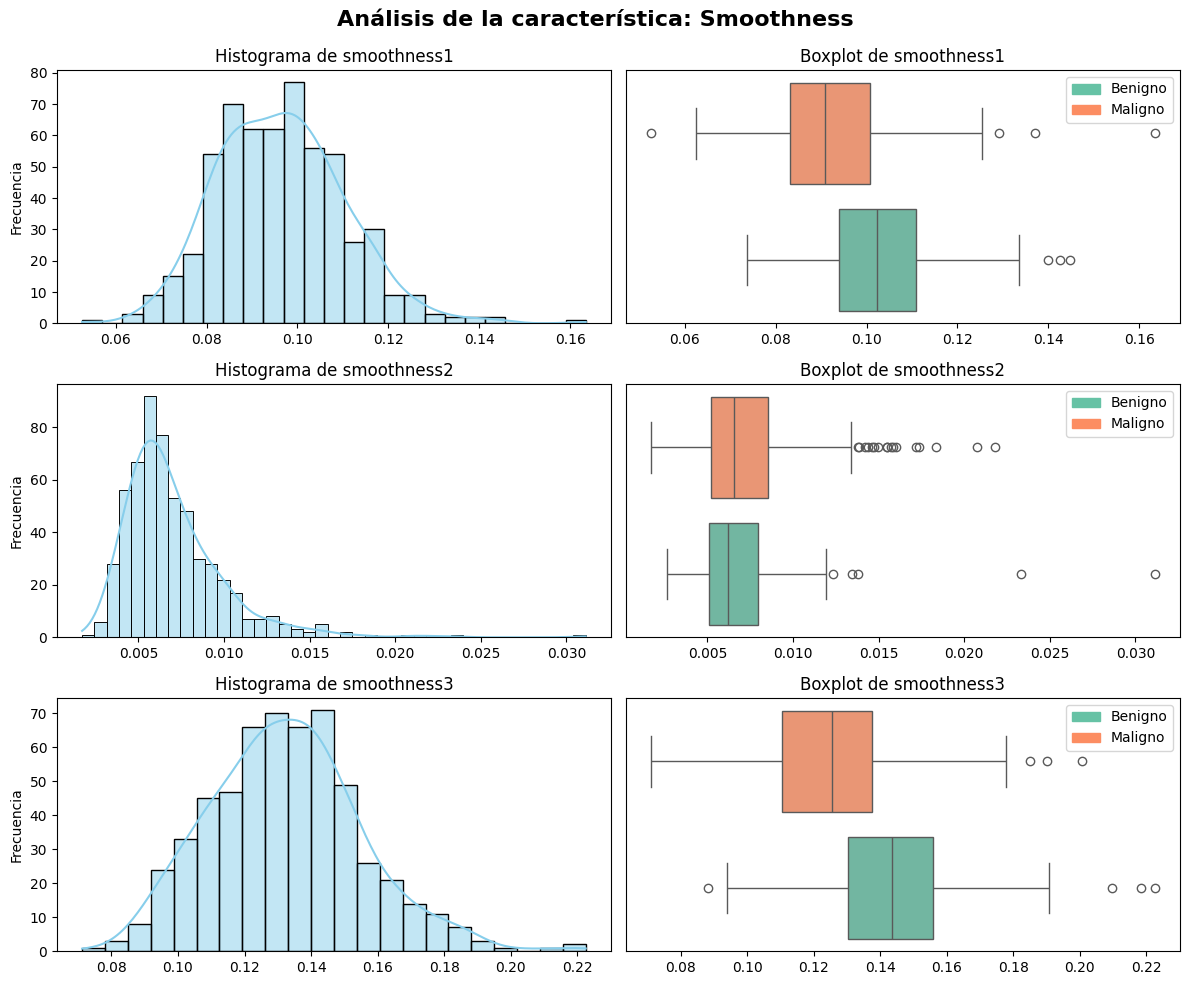

----------------------------------------------------------------------------------------------------


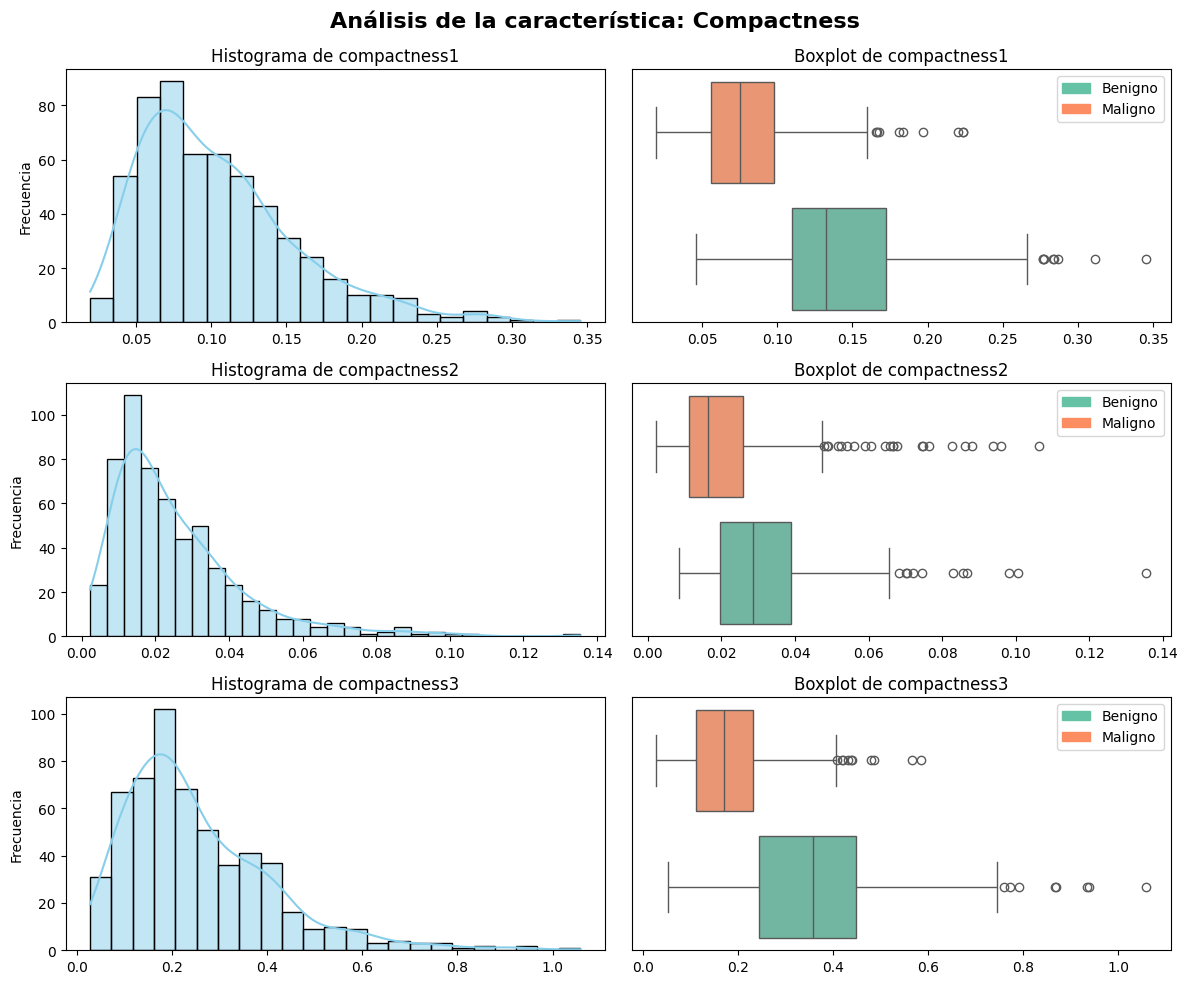

----------------------------------------------------------------------------------------------------


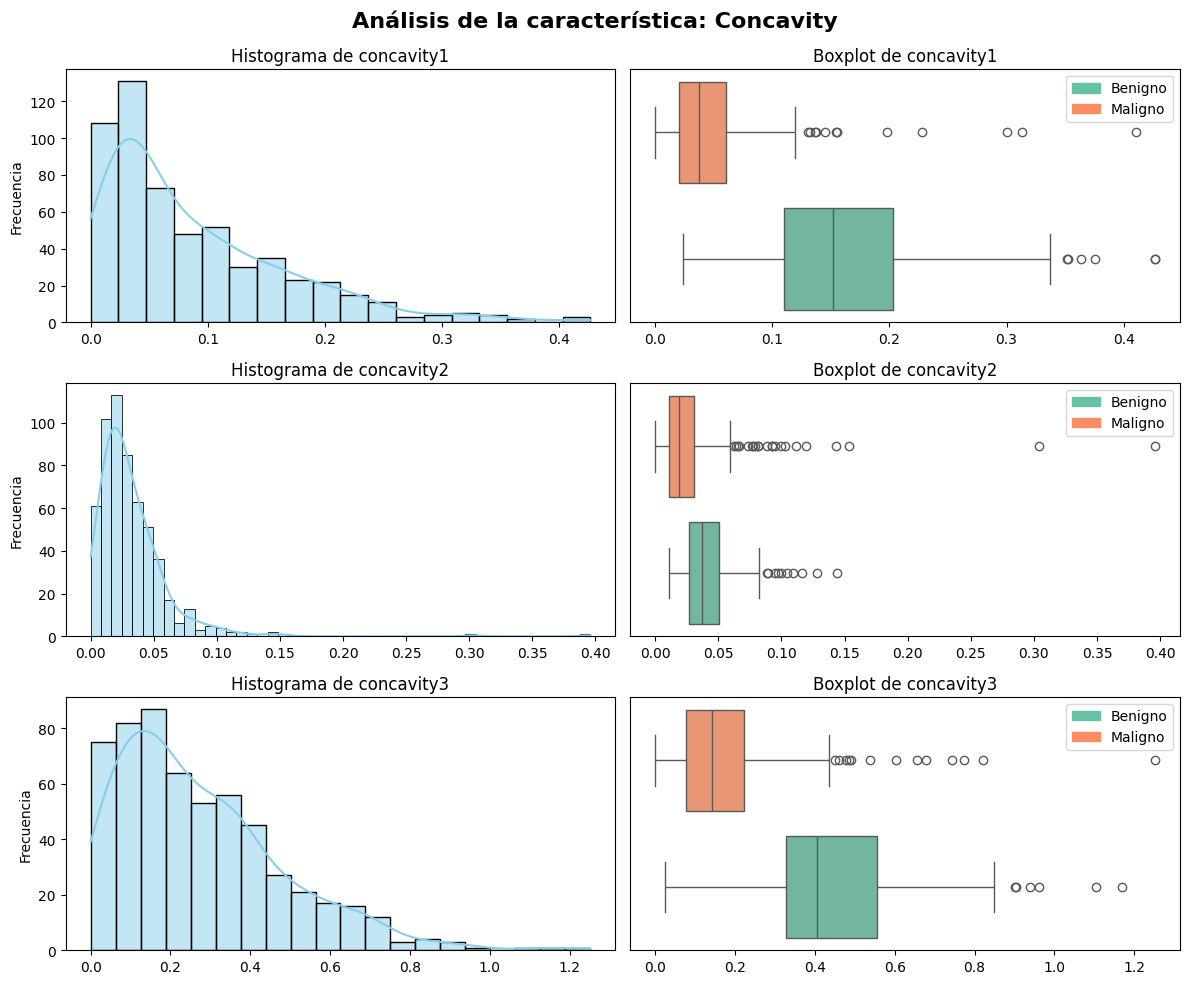

----------------------------------------------------------------------------------------------------


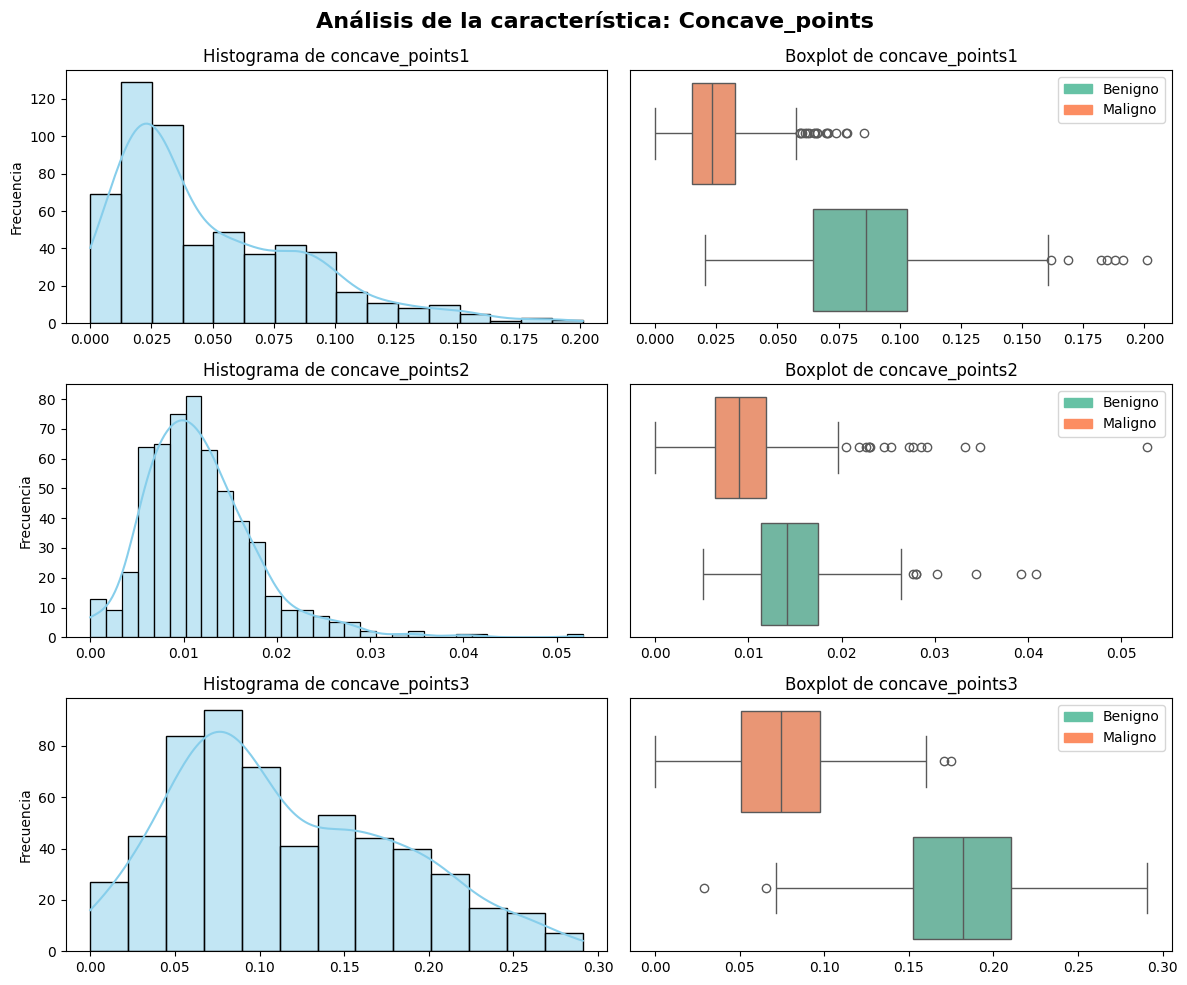

----------------------------------------------------------------------------------------------------


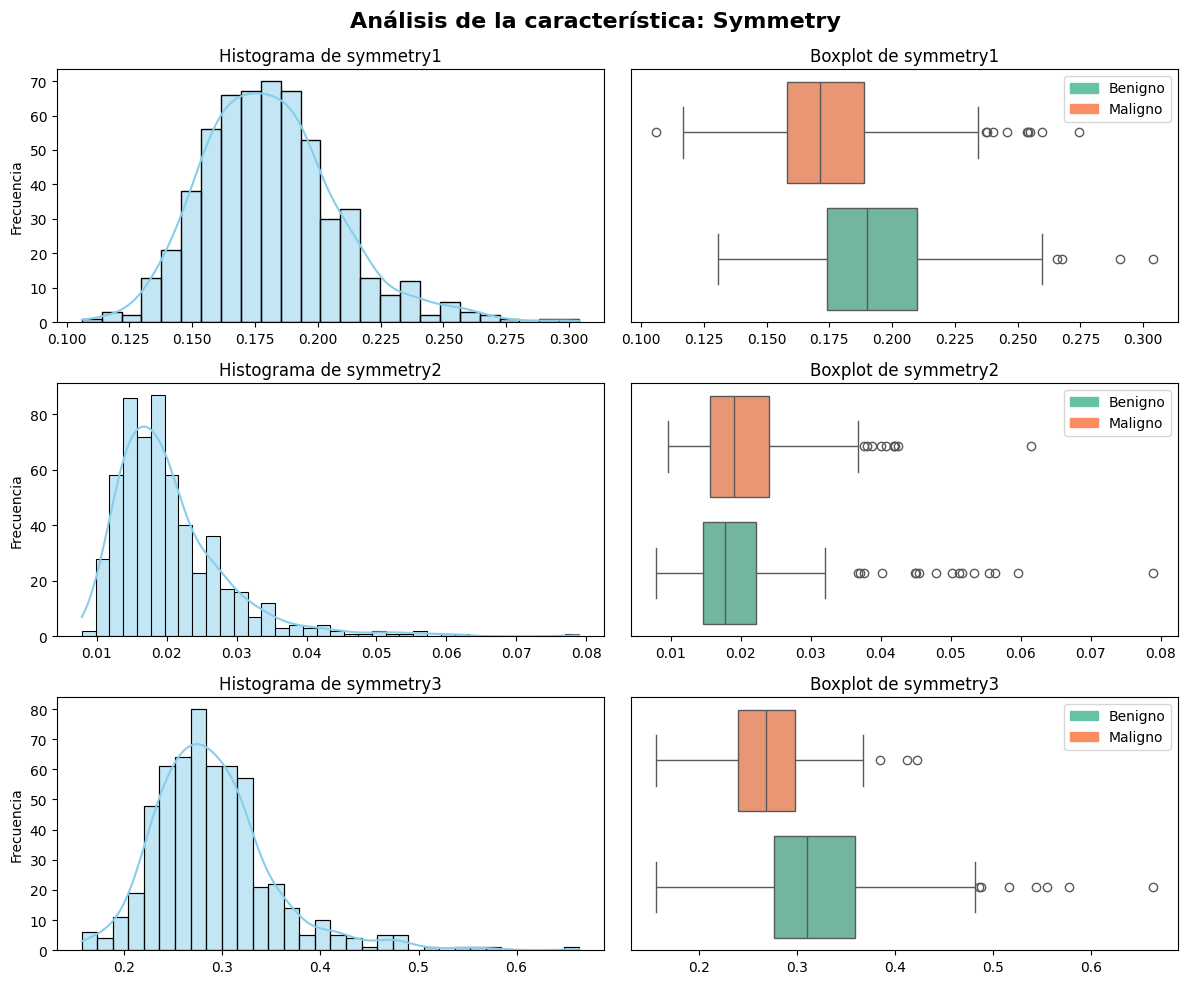

----------------------------------------------------------------------------------------------------


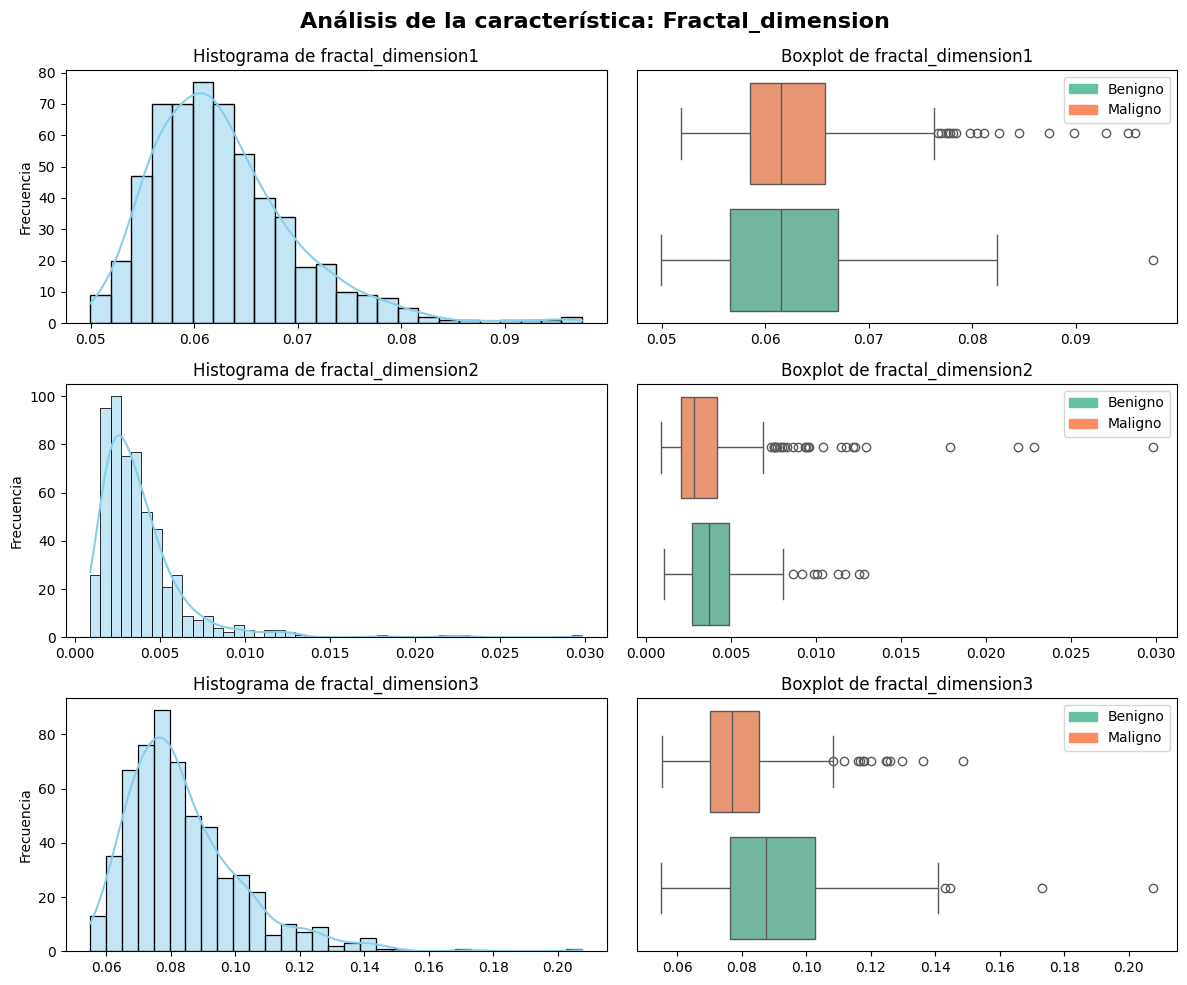

----------------------------------------------------------------------------------------------------


In [8]:
import matplotlib.patches as mpatches

# Crear una copia temporal de los datos para asignar etiquetas claras
df_plot = df.copy()
df_plot['Etiqueta_Diag'] = df_plot['Diagnosis'].map({0: 'Benigno', 1: 'Maligno'})

# Extraer los colores exactos de la paleta 'Set2' que estamos usando
color_benigno = sns.color_palette('Set2')[0]
color_maligno = sns.color_palette('Set2')[1]

# Iterar sobre las 10 características base
for i in range(10):
    col_mean = X.columns[i]
    col_se = X.columns[i + 10]
    col_worst = X.columns[i + 20]
    
    grupo_columnas = [col_mean, col_se, col_worst]
    
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
    
    nombre_base = col_mean.replace('1', '').replace('_mean', '').replace('mean', '').capitalize()
    fig.suptitle(f'Análisis de la característica: {nombre_base}', fontsize=16, fontweight='bold')
    
    for j, col in enumerate(grupo_columnas):
        # 1. Histograma (Izquierda)
        sns.histplot(data=df_plot, x=col, kde=True, ax=axes[j, 0], color='skyblue')
        axes[j, 0].set_title(f'Histograma de {col}')
        axes[j, 0].set_xlabel('')
        axes[j, 0].set_ylabel('Frecuencia')
        
        # 2. Boxplot (Derecha) 
        sns.boxplot(data=df_plot, x=col, y='Etiqueta_Diag', ax=axes[j, 1], 
                    hue='Etiqueta_Diag', palette='Set2', order=['Benigno', 'Maligno'])
        
        axes[j, 1].set_title(f'Boxplot de {col}')
        axes[j, 1].set_xlabel('')
        axes[j, 1].set_ylabel('') 
        axes[j, 1].set_yticks([]) # Ocultar los textos del eje Y
        
        # ==========================================
        # CREACIÓN MANUAL E INFALIBLE DE LA LEYENDA
        # ==========================================
        patch_benigno = mpatches.Patch(color=color_benigno, label='Benigno')
        patch_maligno = mpatches.Patch(color=color_maligno, label='Maligno')
        axes[j, 1].legend(handles=[patch_benigno, patch_maligno], loc='upper right')

    plt.tight_layout()
    fig.subplots_adjust(top=0.92) 
    plt.show()
    
    print("-" * 100)

### 4.1.3. Evaluación y criterio sobre valores atípicos
El gráfico de escala estandarizada permite observar la presencia de valores atípicos (puntos más allá de los bigotes) en la mayoría de las características, destacando especialmente en variables de forma y textura. En el contexto del diagnóstico médico, estos registros representan casos reales de tumores con dimensiones excepcionalmente críticas o morfologías atípicas, por lo que bajo un criterio clínico no se eliminan las muestras para no restar capacidad predictiva al sistema ante casos severos.

## 4.2. Análisis multivariado (Matriz de correlación)
Para evaluar la redundancia de información (colinealidad) entre las 30 características clínicas, se calcula la matriz de correlación lineal de Pearson. Valores cercanos a `1` o `-1` indican que dos variables aportan exactamente la misma información geométrica o estructural del tumor.

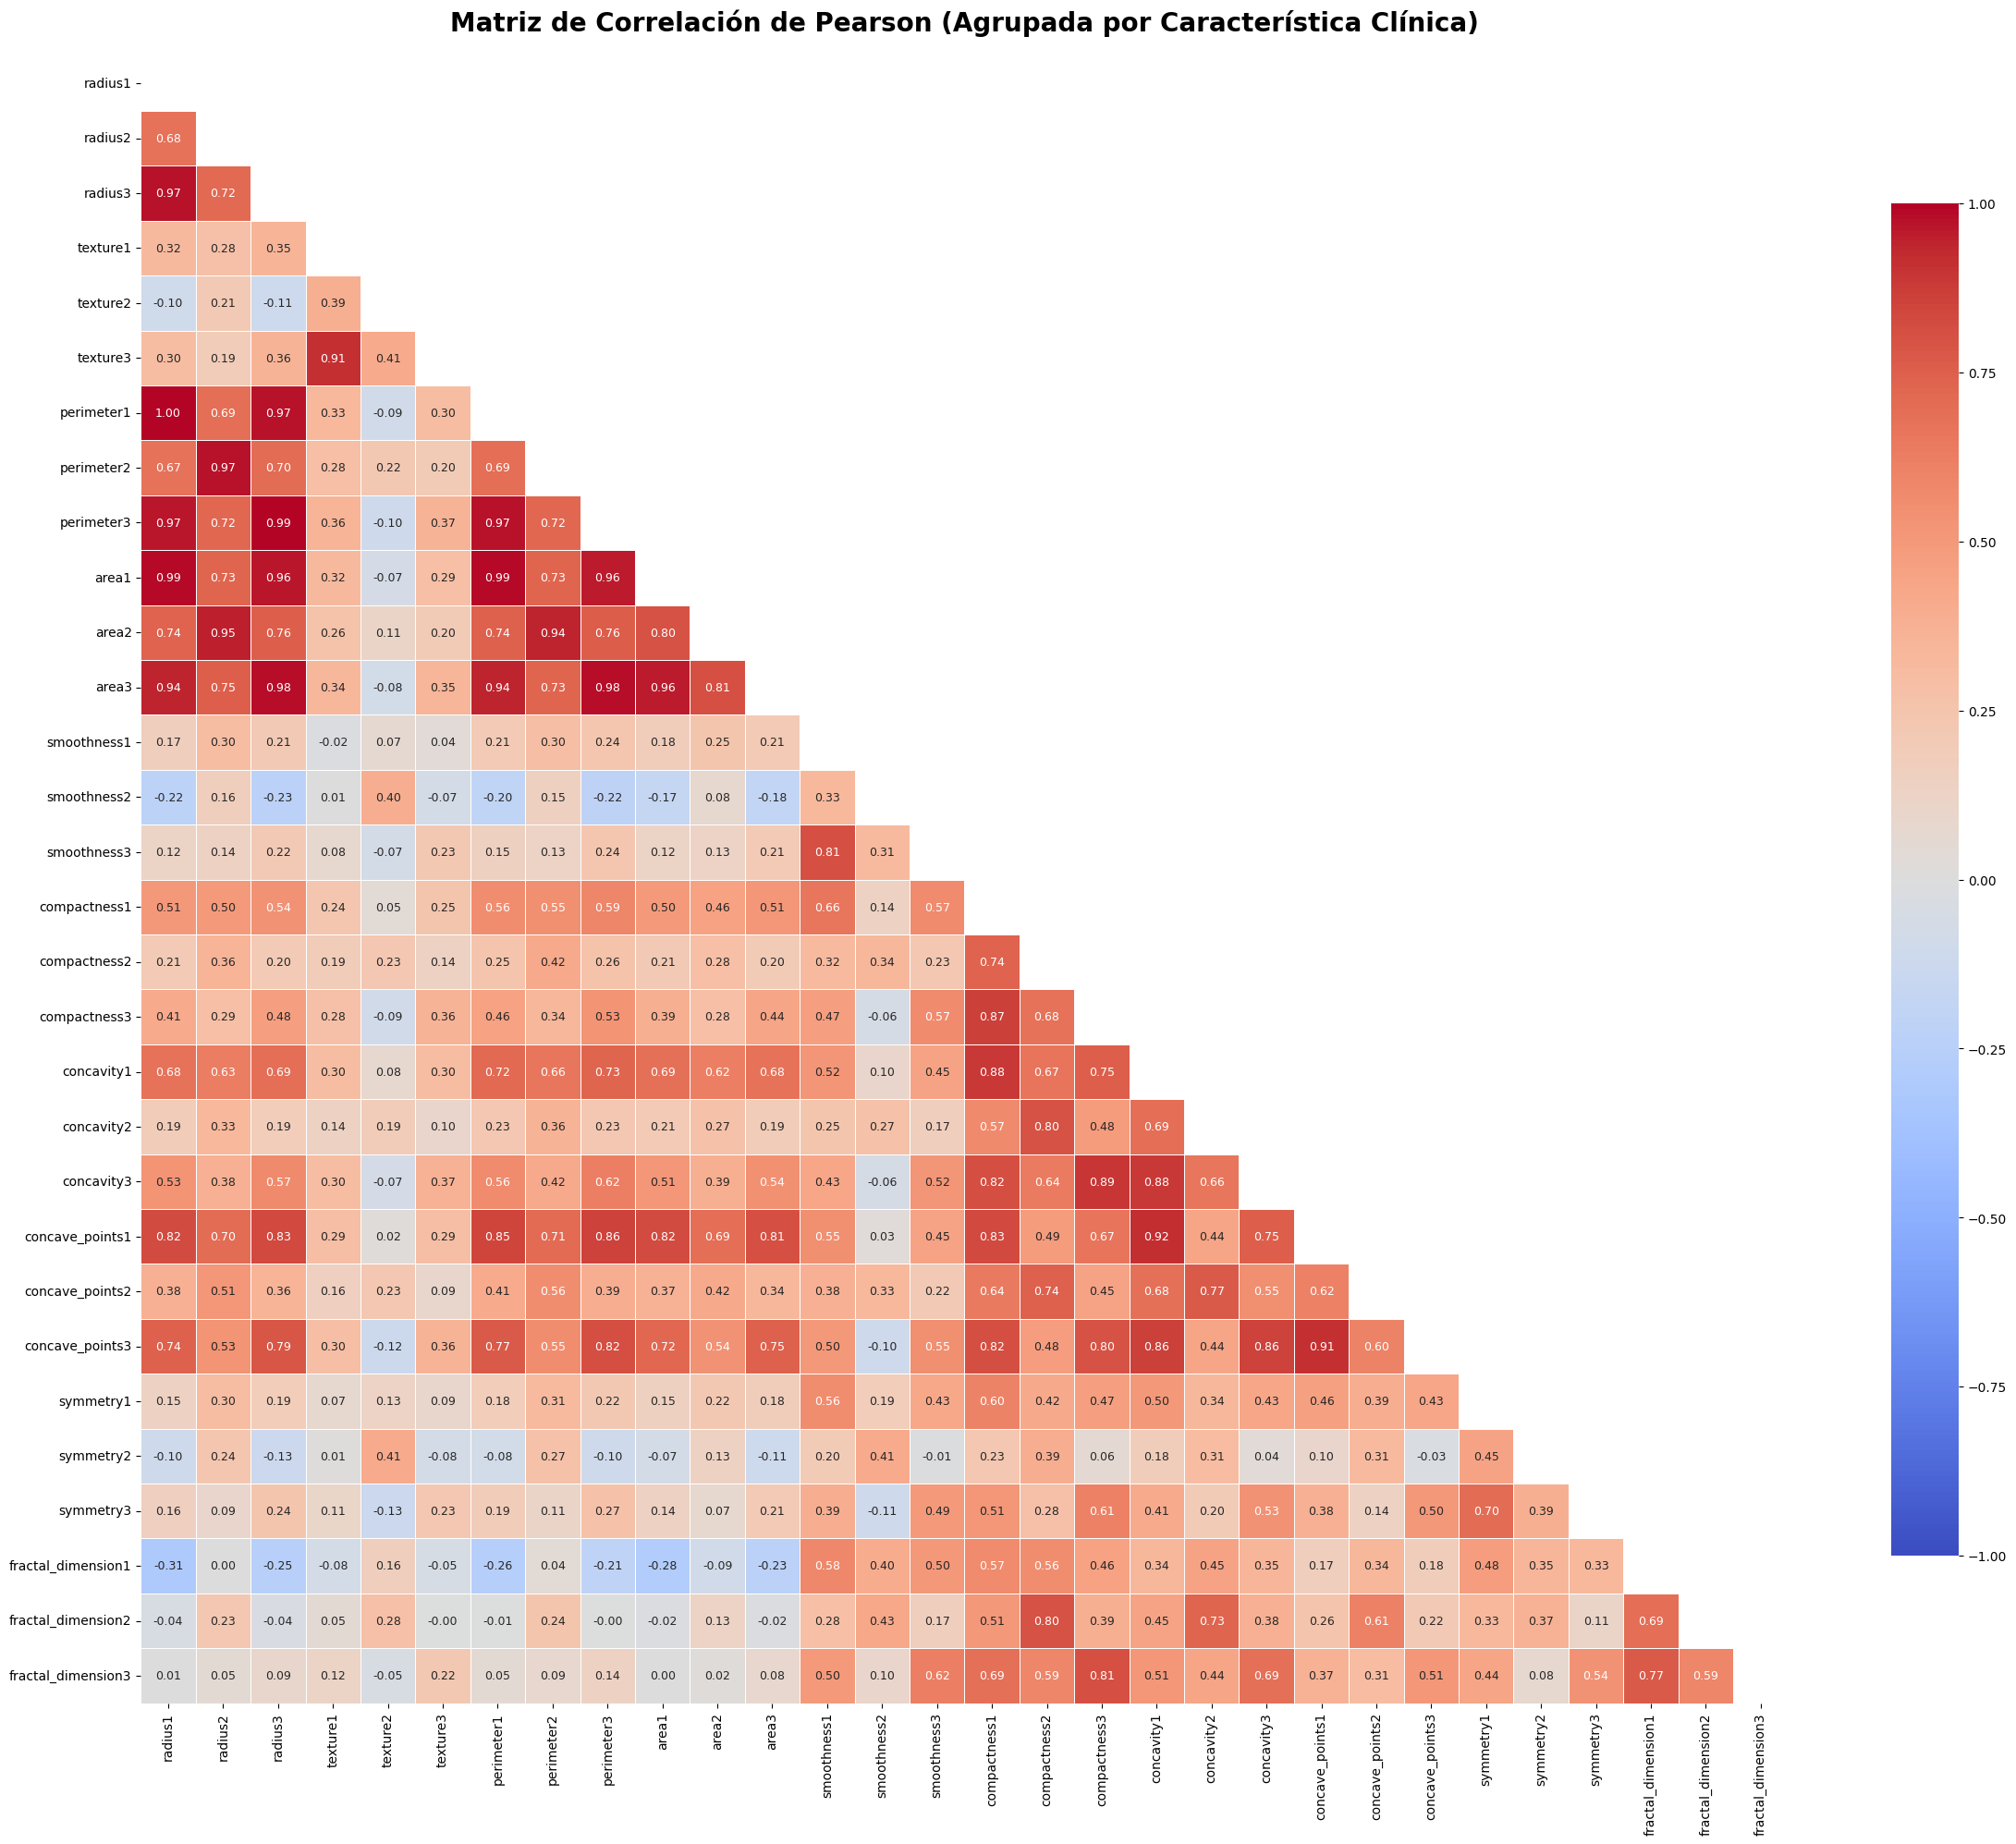

In [9]:
# 1. Reorganizar lógicamente las columnas (Agrupar las 3 medidas por cada característica base)
columnas_ordenadas = []
for i in range(10):
    columnas_ordenadas.append(X.columns[i])       # Promedio (mean)
    columnas_ordenadas.append(X.columns[i + 10])  # Error estándar (se)
    columnas_ordenadas.append(X.columns[i + 20])  # Peor caso (worst)

# 2. Calcular la matriz de correlación usando el DataFrame reordenado
matriz_corr = X[columnas_ordenadas].corr()

# 3. Crear una máscara para ocultar el triángulo superior (para una visualización más limpia)
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))

# 4. Configurar el tamaño de la figura
plt.figure(figsize=(24, 20))
plt.title('Matriz de Correlación de Pearson (Agrupada por Característica Clínica)', fontsize=20, fontweight='bold', pad=20)

# 5. Dibujar el mapa de calor (heatmap)
sns.heatmap(matriz_corr, mask=mascara, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8},
            annot_kws={"size": 9})

plt.tight_layout()
plt.show()

## 4.3. Capacidad predictiva (Correlación con la variable objetivo)
Para tomar decisiones informadas sobre qué variables eliminar en casos de alta multicolinealidad, se calcula la correlación individual de cada característica frente al diagnóstico (`Diagnosis`). Las variables con mayor correlación (positiva o negativa) son las que aportan más información pura al modelo para separar las clases.

C:\Users\aleja\AppData\Local\Temp\ipykernel_15764\3030600544.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_objetivo.values, y=corr_objetivo.index, palette='coolwarm')


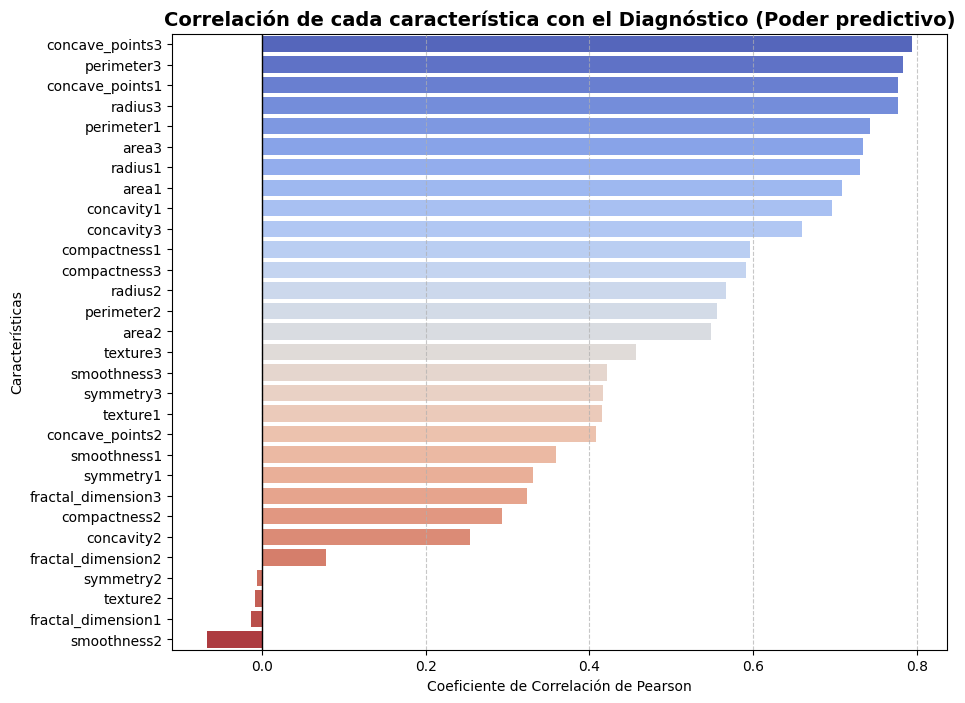

In [10]:
# Calcular correlación con 'Diagnosis' y ordenar de mayor a menor (omitiendo la correlación de Diagnosis consigo misma)
corr_objetivo = df.corr()['Diagnosis'].drop('Diagnosis').sort_values(ascending=False)

# Crear un gráfico de barras horizontal para visualizar el poder predictivo
plt.figure(figsize=(10, 8))
sns.barplot(x=corr_objetivo.values, y=corr_objetivo.index, palette='coolwarm')
plt.title('Correlación de cada característica con el Diagnóstico (Poder predictivo)', fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.ylabel('Características')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.axvline(x=0, color='black', linewidth=1)
plt.show()

## 4.4. Selección algorítmica y eliminación de características
Dada la alta dimensionalidad del dataset y la presencia de múltiples pares de variables correlacionadas, se implementa un algoritmo de selección de características (*Feature Selection*) para garantizar una limpieza sistemática y libre de sesgos humanos. 

El algoritmo evalúa el espacio de características bajo dos reglas matemáticas estrictas:
1. **Filtro de Multicolinealidad (Umbral > 0.85):** Identifica pares de características con alta redundancia de información. Para decidir cuál de las dos variables conservar, el algoritmo evalúa su poder predictivo frente a la variable objetivo (`Diagnosis`), eliminando siempre aquella que aporte menor capacidad de separación de clases.
2. **Filtro de Ruido Estadístico (Umbral < 0.05):** Detecta y elimina características cuya correlación lineal con el diagnóstico es prácticamente nula, ya que solo aportan ruido computacional y favorecen el sobreajuste (*overfitting*).

In [11]:
# 1. Definir umbrales matemáticos
umbral_colinealidad = 0.85  # Si dos variables se parecen más de esto, una debe irse
umbral_ruido = 0.05         # Si una variable tiene menos de esto de poder predictivo, es basura

# 2. Obtener el poder predictivo (Correlación absoluta con Diagnosis)
corr_objetivo = df.corr()['Diagnosis'].drop('Diagnosis').abs()

# 3. Calcular la matriz de correlación solo entre las predictoras (absoluta)
matriz_corr_X = X.corr().abs()

# Lista para guardar las variables condenadas a ser eliminadas
columnas_a_eliminar = set()

# 4. ALGORITMO DE ELIMINACIÓN POR MULTICOLINEALIDAD
# Recorrer el triángulo superior de la matriz para evaluar cada par una sola vez
for i in range(len(matriz_corr_X.columns)):
    for j in range(i+1, len(matriz_corr_X.columns)):
        var1 = matriz_corr_X.columns[i]
        var2 = matriz_corr_X.columns[j]
        
        # Si la correlación entre ellas supera el umbral y ninguna ha sido eliminada aún
        if matriz_corr_X.iloc[i, j] > umbral_colinealidad:
            # Eliminar la que tenga MENOR poder predictivo con el diagnóstico
            if corr_objetivo[var1] < corr_objetivo[var2]:
                columnas_a_eliminar.add(var1)
            else:
                columnas_a_eliminar.add(var2)

# 5. ALGORITMO DE ELIMINACIÓN POR RUIDO ESTADÍSTICO
for col in X.columns:
    if corr_objetivo[col] < umbral_ruido:
        columnas_a_eliminar.add(col)

columnas_a_eliminar = list(columnas_a_eliminar)

# 6. Ejecutar la limpieza
X_limpio = X.drop(columns=columnas_a_eliminar)

print(f"Dimensiones de X original: {X.shape}")
print(f"Dimensiones de X limpio: {X_limpio.shape}")
print(f"Cantidad de variables eliminadas: {len(columnas_a_eliminar)}\n")

print("=== VARIABLES ELIMINADAS ===")
for col in sorted(columnas_a_eliminar):
    print(f"- {col}")

Dimensiones de X original: (569, 30)
Dimensiones de X limpio: (569, 14)
Cantidad de variables eliminadas: 16

=== VARIABLES ELIMINADAS ===
- area1
- area2
- area3
- compactness1
- compactness3
- concave_points1
- concavity1
- concavity3
- fractal_dimension1
- perimeter1
- perimeter2
- radius1
- radius3
- symmetry2
- texture1
- texture2


## 4.5. Conclusiones de la reducción preliminar
La ejecución del algoritmo de filtrado redujo exitosamente el espacio dimensional del problema en un **53%**, pasando de 30 características originales a un espacio optimizado de **14 variables independientes**. 

El análisis de las 16 variables eliminadas confirma las hipótesis exploratorias:
* **Resolución de colinealidad geométrica y morfológica:** El algoritmo purgó exitosamente las familias de variables redundantes. Por ejemplo, eliminó `area1`, `area2`, `area3`, `perimeter1`, `perimeter2`, `radius1` y `radius3`, dejando únicamente los representantes matemáticos con mayor poder predictivo de cada grupo para representar el tamaño de la célula. Lo mismo ocurrió con las medidas de forma (`concavity1`, `concavity3`, `compactness1`, `compactness3` y `concave_points1`).
* **Purga de ruido estadístico:** Se eliminaron variables como `fractal_dimension1`, `symmetry2` y `texture2`, validando que no contenían patrones lineales útiles para el diagnóstico médico.

Este conjunto de datos reducido (`X_limpio`) representa una base matemática mucho más estable para los clasificadores que se entrenarán a continuación, mitigando el riesgo de inestabilidad en los pesos de los algoritmos y mejorando la eficiencia computacional del sistema.

# 5. Entrenamiento y Evaluación de los Modelos

## 5.1. Configuración experimental
Para garantizar la validez metodológica del entrenamiento y prevenir el sobreajuste (*overfitting*), se define el siguiente esquema de validación:

1. **División Holdout (70/30):** El conjunto de datos reducido se divide en un 70% para el entrenamiento y validación interna de los algoritmos, y un 30% estrictamente reservado como conjunto de prueba (Test) independiente. Se utiliza muestreo estratificado para mantener la proporción original de tumores benignos y malignos en ambos subconjuntos.
2. **Estandarización:** Debido a que clasificadores basados en distancias (k-NN) y optimización geométrica (SVM) son altamente sensibles a la escala de las variables, se aplica una normalización Z-score (`StandardScaler`). Para evitar fuga de datos (*Data Leakage*), los parámetros de escalado ($\mu$ y $\sigma$) se calculan exclusivamente sobre el conjunto de entrenamiento y luego se aplican al conjunto de prueba.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Extraer la variable objetivo como un arreglo 1D (requerido por Scikit-Learn)
y_target = df['Diagnosis'].values

# 2. División de los datos (70% Entrenamiento, 30% Prueba)
# stratify=y_target asegura que ambos conjuntos tengan el mismo % de casos malignos
X_train, X_test, y_train, y_test = train_test_split(
    X_limpio, y_target, test_size=0.30, random_state=30, stratify=y_target
)

# 3. Estandarización de los datos (Z-score)
scaler = StandardScaler()

# Se ajusta (fit) SOLO con entrenamiento y se transforma
X_train_scaled = scaler.fit_transform(X_train)

# El test SOLO se transforma (usando la media y varianza del entrenamiento)
X_test_scaled = scaler.transform(X_test)

print("=== CONFIGURACIÓN EXPERIMENTAL COMPLETADA ===")
print(f"Total de muestras originales: {len(X_limpio)}")
print(f"Muestras para Entrenamiento/Validación (70%): {X_train_scaled.shape[0]}")
print(f"Muestras reservadas para Test (30%): {X_test_scaled.shape[0]}")
print(f"Cantidad de características activas: {X_train_scaled.shape[1]}")

=== CONFIGURACIÓN EXPERIMENTAL COMPLETADA ===
Total de muestras originales: 569
Muestras para Entrenamiento/Validación (70%): 398
Muestras reservadas para Test (30%): 171
Cantidad de características activas: 14


## 5.1.5. Visualización del Espacio Latente (PCA)
Para comprender visualmente la separabilidad de las clases tras la estandarización y limpieza de las variables, se aplica el Análisis de Componentes Principales (PCA). Esta técnica proyecta las 14 dimensiones actuales en un espacio bidimensional (2D) maximizando la varianza retenida. Esto nos permite observar gráficamente si existe una frontera de decisión clara entre tumores benignos y malignos antes de aplicar algoritmos más complejos.

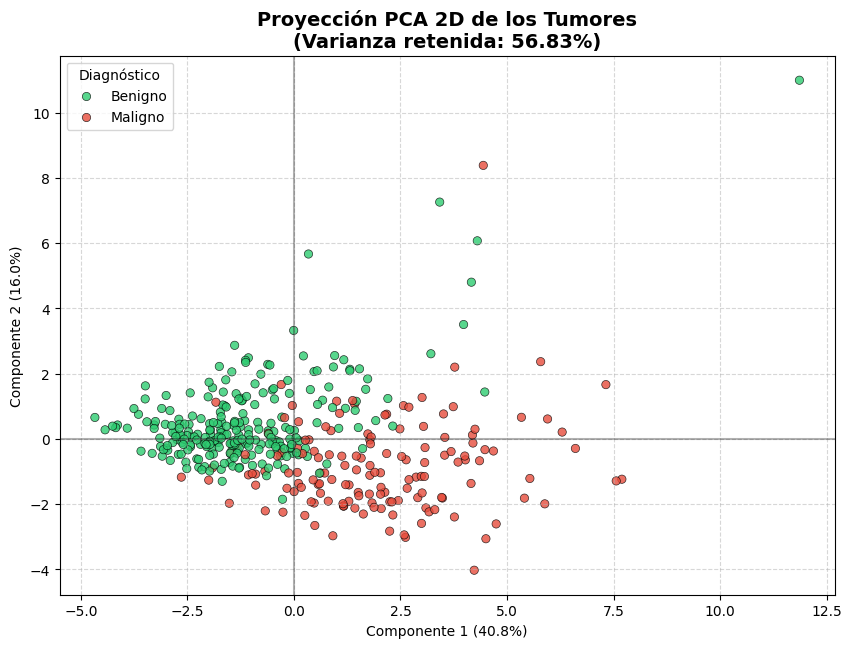

In [13]:
from sklearn.decomposition import PCA
import pandas as pd

# 1. Instanciar PCA para reducir a solo 2 componentes (2D)
pca = PCA(n_components=2, random_state=30)

# 2. Aplicar PCA sobre los datos de entrenamiento ya estandarizados
X_train_pca = pca.fit_transform(X_train_scaled)

# 3. Calcular cuánta información (varianza) logramos salvar en solo 2 variables
varianza_retenida = sum(pca.explained_variance_ratio_) * 100

# 4. Crear un DataFrame temporal para graficar fácilmente
df_pca = pd.DataFrame(data=X_train_pca, columns=['Componente Principal 1', 'Componente Principal 2'])
df_pca['Diagnóstico'] = y_train # Agregamos la etiqueta real

# Reemplazar 0 y 1 por los nombres para la leyenda
df_pca['Diagnóstico'] = df_pca['Diagnóstico'].map({0: 'Benigno', 1: 'Maligno'})

# 5. Graficar el espacio 2D
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Componente Principal 1', 
    y='Componente Principal 2',
    hue='Diagnóstico',
    palette=['#2ecc71', '#e74c3c'], # Verde para benigno, Rojo para maligno
    data=df_pca,
    alpha=0.8,
    edgecolor='k'
)

plt.title(f'Proyección PCA 2D de los Tumores\n(Varianza retenida: {varianza_retenida:.2f}%)', fontsize=14, fontweight='bold')
plt.xlabel(f'Componente 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Componente 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.show()

## 5.2. Entrenamiento y Evaluación de Modelos

### 5.2.1. Modelo 1: Regresión Logística (Paramétrico)
La regresión logística es un modelo probabilístico lineal que estima la probabilidad de que una muestra pertenezca a una clase particular. Para optimizar su rendimiento, se implementa una búsqueda exhaustiva de hiperparámetros (`GridSearchCV`) evaluando el factor de regularización (`C`) y el método de optimización (`solver`) mediante validación cruzada de 5 pliegues (5-fold CV).

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import time

# 1. Definir el modelo base
lr_model = LogisticRegression(max_iter=2000, random_state=42)

# 2. Definir la malla de hiperparámetros a explorar
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],      # Inverso de la fuerza de regularización
    'solver': ['liblinear', 'lbfgs'],  # Algoritmos de optimización
    'penalty': ['l2']                  # Penalización estándar
}

# 3. Configurar GridSearchCV
grid_lr = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid_lr,
    cv=5,                              # Validación cruzada de 5 pliegues
    scoring='accuracy',                # Métrica a optimizar
    n_jobs=-1                          # Usar todos los procesadores disponibles
)

# 4. Entrenar el modelo (Ajuste)
print("Entrenando Regresión Logística...")
start_time = time.time()
grid_lr.fit(X_train_scaled, y_train)
end_time = time.time()

# 5. Extraer el mejor modelo encontrado
best_lr = grid_lr.best_estimator_

print(f"Entrenamiento completado en {end_time - start_time:.2f} segundos.")
print(f"Mejores hiperparámetros encontrados: {grid_lr.best_params_}")
print(f"Exactitud (Accuracy) interna en validación cruzada: {grid_lr.best_score_ * 100:.2f}%")

Entrenando Regresión Logística...
Entrenamiento completado en 4.44 segundos.
Mejores hiperparámetros encontrados: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Exactitud (Accuracy) interna en validación cruzada: 96.73%


C:\Users\aleja\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


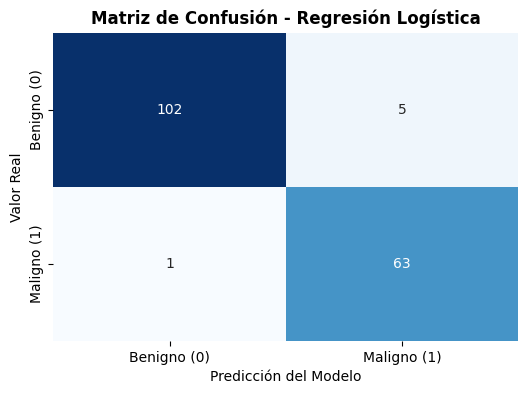

=== REPORTE DE CLASIFICACIÓN (CONJUNTO DE PRUEBA) ===
              precision    recall  f1-score   support

 Benigno (0)       0.99      0.95      0.97       107
 Maligno (1)       0.93      0.98      0.95        64

    accuracy                           0.96       171
   macro avg       0.96      0.97      0.96       171
weighted avg       0.97      0.96      0.97       171

Exactitud final en Test: 96.49%


In [15]:
# 1. Predecir sobre el conjunto de prueba (30% reservado)
y_pred_lr = best_lr.predict(X_test_scaled)

# 2. Calcular la matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)

# 3. Visualizar la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benigno (0)', 'Maligno (1)'], 
            yticklabels=['Benigno (0)', 'Maligno (1)'])
plt.title('Matriz de Confusión - Regresión Logística', fontweight='bold')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

# 4. Imprimir el reporte de métricas de clasificación
print("=== REPORTE DE CLASIFICACIÓN (CONJUNTO DE PRUEBA) ===")
print(classification_report(y_test, y_pred_lr, target_names=['Benigno (0)', 'Maligno (1)']))
print(f"Exactitud final en Test: {accuracy_score(y_test, y_pred_lr) * 100:.2f}%")

#### Análisis de Resultados: Regresión Logística
El modelo paramétrico lineal (optimizado con hiperparámetros `C=10` y `solver='lbfgs'`) obtuvo una exactitud del 96.49% en el conjunto de prueba. Sin embargo, su verdadero valor destaca en el análisis discriminado de sus errores desde una perspectiva clínica:

* **Alta Sensibilidad / Recall (0.98):** El modelo priorizó fuertemente la detección de la clase minoritaria y crítica. Logró identificar correctamente a 63 de los 64 pacientes con tumores malignos, minimizando el riesgo de falsos negativos (solo 1 caso no detectado).
* **Trade-off de Precisión (0.93):** Como contraprestación matemática para alcanzar un Recall tan elevado, el modelo sacrificó precisión, generando algunas falsas alarmas (falsos positivos). 

En el contexto del tamizaje oncológico, este comportamiento conservador es ideal: se prefiere someter a pacientes sanos a exámenes secundarios preventivos, antes que omitir un diagnóstico de cáncer real. Este modelo establece una línea base clínica excepcionalmente robusta para el resto del experimento.

### 5.2.2. Modelo 2: k-Nearest Neighbors (k-NN)
El algoritmo de los k-Vecinos Más Cercanos es un modelo no paramétrico que clasifica las muestras basándose en la proximidad espacial de las características. Al estar basado en el cálculo de distancias, este algoritmo se beneficia directamente de la estandarización `Z-score` aplicada previamente, la cual evita que características con escalas mayores dominen el cálculo de vecindad. 

Para su optimización, se utiliza `GridSearchCV` evaluando:
* `n_neighbors`: La cantidad de vecinos a consultar (la "K" del modelo).
* `weights`: Si todos los vecinos votan igual (`uniform`) o si los más cercanos tienen más peso (`distance`).
* `metric`: La fórmula matemática para medir la distancia en el espacio multidimensional (`euclidean`, `manhattan`, `minkowski`).

Entrenando k-Nearest Neighbors...
Entrenamiento completado en 4.41 segundos.
Mejores hiperparámetros encontrados: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Exactitud (Accuracy) interna en validación cruzada: 94.22%



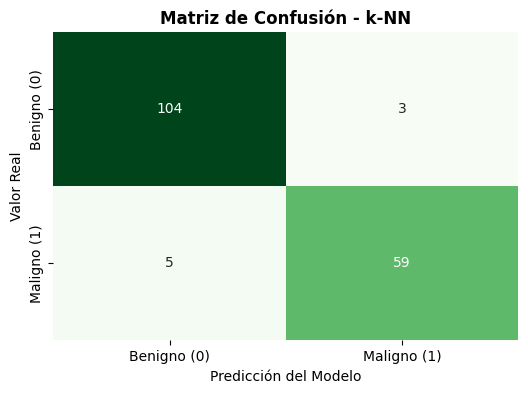

=== REPORTE DE CLASIFICACIÓN (k-NN) ===
              precision    recall  f1-score   support

 Benigno (0)       0.95      0.97      0.96       107
 Maligno (1)       0.95      0.92      0.94        64

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171

Exactitud final en Test: 95.32%


In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import time
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir el modelo base
knn_model = KNeighborsClassifier()

# 2. Definir la malla de hiperparámetros a explorar
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],             # Cantidad de vecinos a consultar
    'weights': ['uniform', 'distance'],              # Peso de los votos
    'metric': ['euclidean', 'manhattan', 'minkowski']# Métricas de distancia espacial
}

# 3. Configurar GridSearchCV con nuestra pista de 5 pliegues
grid_knn = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid_knn,
    cv=5,                              # Validación cruzada (k=5 pliegues)
    scoring='accuracy',                # Optimizando la exactitud
    n_jobs=-1                          # Acelerar el cómputo usando todos los procesadores
)

# 4. Entrenar el modelo (Ajuste)
print("Entrenando k-Nearest Neighbors...")
start_time = time.time()
grid_knn.fit(X_train_scaled, y_train)
end_time = time.time()

# Extraer el campeón de los torneos
best_knn = grid_knn.best_estimator_

print(f"Entrenamiento completado en {end_time - start_time:.2f} segundos.")
print(f"Mejores hiperparámetros encontrados: {grid_knn.best_params_}")
print(f"Exactitud (Accuracy) interna en validación cruzada: {grid_knn.best_score_ * 100:.2f}%\n")

# 5. Evaluación en Test (El examen final sorpresivo)
y_pred_knn = best_knn.predict(X_test_scaled)
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Visualizar Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Benigno (0)', 'Maligno (1)'], 
            yticklabels=['Benigno (0)', 'Maligno (1)'])
plt.title('Matriz de Confusión - k-NN', fontweight='bold')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

# Imprimir el reporte clínico
print("=== REPORTE DE CLASIFICACIÓN (k-NN) ===")
print(classification_report(y_test, y_pred_knn, target_names=['Benigno (0)', 'Maligno (1)']))
print(f"Exactitud final en Test: {accuracy_score(y_test, y_pred_knn) * 100:.2f}%")

### 5.2.3. Modelo 3: Máquinas de Vectores de Soporte (SVM)
Las Máquinas de Vectores de Soporte buscan encontrar el hiperplano óptimo que maximice el margen de separación entre las clases benigna y maligna. Dado que este modelo fundamenta su optimización en distancias geométricas, la estandarización `Z-score` previa es un requisito estricto para su convergencia.

Se implementa `GridSearchCV` para explorar los siguientes hiperparámetros:
* `C`: Parámetro de regularización que penaliza los errores de clasificación en el margen.
* `kernel`: Función matemática para la transformación del espacio de características (`linear`, `rbf`, `poly`), permitiendo resolver separaciones no lineales.
* `gamma`: Coeficiente del kernel que define la influencia de una muestra de entrenamiento individual.

Entrenando Máquina de Vectores de Soporte (SVM)...
Entrenamiento completado en 4.38 segundos.
Mejores hiperparámetros encontrados: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Exactitud interna en validación cruzada: 96.98%



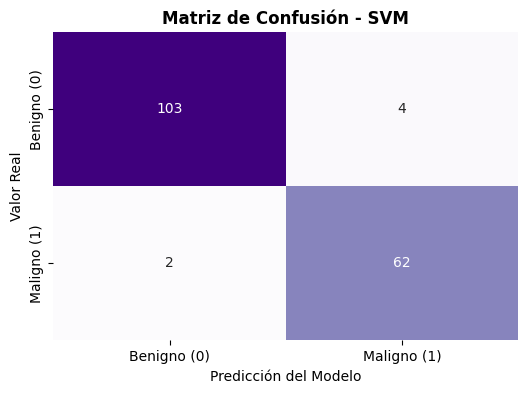

=== REPORTE DE CLASIFICACIÓN (SVM) ===
              precision    recall  f1-score   support

 Benigno (0)       0.98      0.96      0.97       107
 Maligno (1)       0.94      0.97      0.95        64

    accuracy                           0.96       171
   macro avg       0.96      0.97      0.96       171
weighted avg       0.97      0.96      0.97       171

Exactitud final en Test: 96.49%


In [17]:
from sklearn.svm import SVC

# 1. Definir el modelo base (fijamos la semilla para que sea reproducible)
svm_model = SVC(random_state=30)

# 2. Definir la malla de hiperparámetros a explorar
param_grid_svm = {
    'C': [0.1, 1, 10, 100],                  # Regularización (ancho de la autopista)
    'kernel': ['linear', 'rbf', 'poly'],     # Tipo de transformación espacial
    'gamma': ['scale', 'auto']               # Radio de influencia (solo para rbf y poly)
}

# 3. Configurar GridSearchCV con nuestra pista oficial (cv=5)
grid_svm = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 4. Entrenar el modelo (Ajuste)
print("Entrenando Máquina de Vectores de Soporte (SVM)...")
start_time = time.time()
grid_svm.fit(X_train_scaled, y_train)
end_time = time.time()

# Extraer el campeón
best_svm = grid_svm.best_estimator_

print(f"Entrenamiento completado en {end_time - start_time:.2f} segundos.")
print(f"Mejores hiperparámetros encontrados: {grid_svm.best_params_}")
print(f"Exactitud interna en validación cruzada: {grid_svm.best_score_ * 100:.2f}%\n")

# 5. Evaluación en Test (Examen Final)
y_pred_svm = best_svm.predict(X_test_scaled)
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Visualizar Matriz
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Benigno (0)', 'Maligno (1)'], 
            yticklabels=['Benigno (0)', 'Maligno (1)'])
plt.title('Matriz de Confusión - SVM', fontweight='bold')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

# Imprimir el reporte
print("=== REPORTE DE CLASIFICACIÓN (SVM) ===")
print(classification_report(y_test, y_pred_svm, target_names=['Benigno (0)', 'Maligno (1)']))
print(f"Exactitud final en Test: {accuracy_score(y_test, y_pred_svm) * 100:.2f}%")

### 5.2.4. Modelo 4: Ensamble de Árboles (Random Forest)
El Bosque Aleatorio es un modelo de aprendizaje por ensamble basado en la técnica de *Bagging* (Bootstrap Aggregating). Construye múltiples árboles de decisión independientes sobre submuestras del conjunto de entrenamiento y utiliza votación mayoritaria para la predicción final. Esto reduce significativamente la varianza y el riesgo de sobreajuste comparado con un árbol de decisión individual.

Para este modelo, se exploran hiperparámetros que controlan la arquitectura del bosque y la complejidad de los árboles subyacentes:
* `n_estimators`: Número total de árboles en el ensamble.
* `max_depth`: Profundidad máxima permitida para cada árbol (control de sobreajuste).
* `min_samples_split`: Cantidad mínima de muestras requeridas para dividir un nodo interno.

Entrenando Bosque Aleatorio (Random Forest)...
Entrenamiento completado en 8.82 segundos.
Mejores hiperparámetros encontrados: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Exactitud interna en validación cruzada: 95.48%



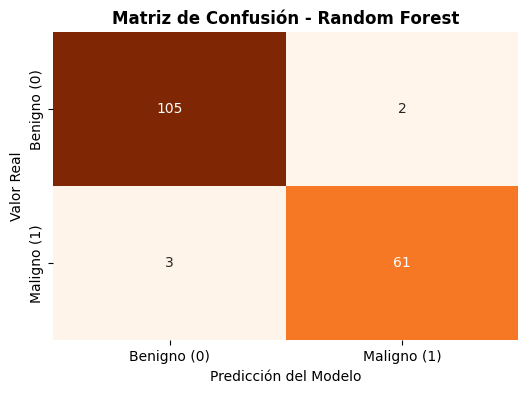

=== REPORTE DE CLASIFICACIÓN (RANDOM FOREST) ===
              precision    recall  f1-score   support

 Benigno (0)       0.97      0.98      0.98       107
 Maligno (1)       0.97      0.95      0.96        64

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171

Exactitud final en Test: 97.08%


In [18]:
from sklearn.ensemble import RandomForestClassifier

# 1. Definir el modelo base (fijamos la semilla para la aleatoriedad del bosque)
rf_model = RandomForestClassifier(random_state=30)

# 2. Definir la malla de hiperparámetros a explorar
param_grid_rf = {
    'n_estimators': [50, 100, 200],         # Cantidad de árboles
    'max_depth': [None, 5, 10, 15],         # Profundidad máxima de los árboles
    'min_samples_split': [2, 5, 10]         # Muestras mínimas para dividir
}

# 3. Configurar GridSearchCV
grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,                              # Nuestros 5 torneos de validación
    scoring='accuracy',
    n_jobs=-1
)

# 4. Entrenar el ensamble
print("Entrenando Bosque Aleatorio (Random Forest)...")
start_time = time.time()
grid_rf.fit(X_train_scaled, y_train)
end_time = time.time()

# Extraer el mejor bosque
best_rf = grid_rf.best_estimator_

print(f"Entrenamiento completado en {end_time - start_time:.2f} segundos.")
print(f"Mejores hiperparámetros encontrados: {grid_rf.best_params_}")
print(f"Exactitud interna en validación cruzada: {grid_rf.best_score_ * 100:.2f}%\n")

# 5. Evaluación en el Test
y_pred_rf = best_rf.predict(X_test_scaled)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Visualizar Matriz
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Benigno (0)', 'Maligno (1)'], 
            yticklabels=['Benigno (0)', 'Maligno (1)'])
plt.title('Matriz de Confusión - Random Forest', fontweight='bold')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

# Imprimir el reporte
print("=== REPORTE DE CLASIFICACIÓN (RANDOM FOREST) ===")
print(classification_report(y_test, y_pred_rf, target_names=['Benigno (0)', 'Maligno (1)']))
print(f"Exactitud final en Test: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")

### 5.2.5. Modelo 5: Red Neuronal Artificial (Perceptrón Multicapa - MLP)
El Perceptrón Multicapa (MLP) es un modelo no lineal que aproxima funciones complejas mediante la interconexión de capas de neuronas artificiales. Este algoritmo es extremadamente sensible a la magnitud de los datos de entrada, por lo que la estandarización `Z-score` previa es indispensable para garantizar la convergencia del algoritmo de optimización (gradiente descendente).

Se utiliza `GridSearchCV` para encontrar la topología y configuración óptima de la red:
* `hidden_layer_sizes`: Arquitectura de la red (número de capas ocultas y neuronas por capa).
* `activation`: Función de activación no lineal introducida en las neuronas.
* `alpha`: Parámetro de penalización L2 (regularización) para controlar la magnitud de los pesos sinápticos y prevenir el sobreajuste.

Entrenando Red Neuronal Artificial (MLP)...
Entrenamiento completado en 4.81 segundos.
Mejores hiperparámetros encontrados: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50,)}
Exactitud interna en validación cruzada: 96.98%



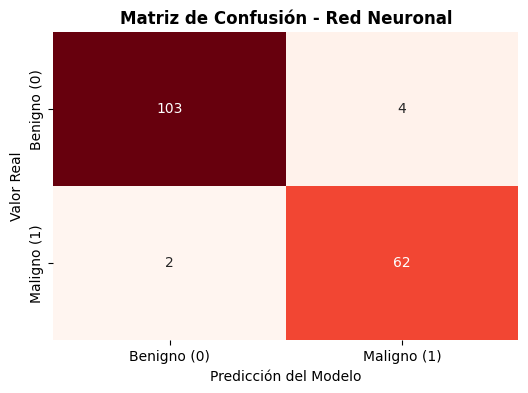

=== REPORTE DE CLASIFICACIÓN (RED NEURONAL) ===
              precision    recall  f1-score   support

 Benigno (0)       0.98      0.96      0.97       107
 Maligno (1)       0.94      0.97      0.95        64

    accuracy                           0.96       171
   macro avg       0.96      0.97      0.96       171
weighted avg       0.97      0.96      0.97       171

Exactitud final en Test: 96.49%


In [19]:
from sklearn.neural_network import MLPClassifier

# 1. Definir la Red Neuronal (aumentamos iteraciones porque las redes requieren más tiempo para aprender)
mlp_model = MLPClassifier(max_iter=2000, random_state=30)

# 2. Definir la malla de hiperparámetros
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)], # 1 capa de 50, 1 de 100, o 2 capas de 50
    'activation': ['relu', 'tanh'],                  # Funciones de activación
    'alpha': [0.0001, 0.01, 0.1]                     # Penalización L2 (regularización)
}

# 3. Configurar GridSearchCV
grid_mlp = GridSearchCV(
    estimator=mlp_model,
    param_grid=param_grid_mlp,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 4. Entrenar la Red Neuronal
print("Entrenando Red Neuronal Artificial (MLP)...")
start_time = time.time()
grid_mlp.fit(X_train_scaled, y_train)
end_time = time.time()

# Extraer la mejor red
best_mlp = grid_mlp.best_estimator_

print(f"Entrenamiento completado en {end_time - start_time:.2f} segundos.")
print(f"Mejores hiperparámetros encontrados: {grid_mlp.best_params_}")
print(f"Exactitud interna en validación cruzada: {grid_mlp.best_score_ * 100:.2f}%\n")

# 5. Evaluación en Test
y_pred_mlp = best_mlp.predict(X_test_scaled)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

# Visualizar Matriz
plt.figure(figsize=(6, 4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Benigno (0)', 'Maligno (1)'], 
            yticklabels=['Benigno (0)', 'Maligno (1)'])
plt.title('Matriz de Confusión - Red Neuronal', fontweight='bold')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

# Imprimir reporte
print("=== REPORTE DE CLASIFICACIÓN (RED NEURONAL) ===")
print(classification_report(y_test, y_pred_mlp, target_names=['Benigno (0)', 'Maligno (1)']))
print(f"Exactitud final en Test: {accuracy_score(y_test, y_pred_mlp) * 100:.2f}%")

# 6. Conclusión y Comparación de Modelos
Para determinar el modelo más apto para el diagnóstico oncológico, se consolida el rendimiento de los 5 algoritmos evaluados frente al conjunto de prueba (Test). Dado el contexto médico, el criterio de selección principal priorizará el *Recall (Sensibilidad)* sobre la clase maligna para minimizar los falsos negativos, utilizando la *Exactitud (Accuracy)* y la *Precisión* como criterios de desempate.

=== TABLA COMPARATIVA DE RENDIMIENTO ===


,Algoritmo,Exactitud Global (%),Precisión Maligno (%),Recall Maligno (%),F1-Score (%)
0,Regresión Logística,96.49,92.65,98.44,95.45
1,SVM (Lineal),96.49,93.94,96.88,95.38
2,Red Neuronal (MLP),96.49,93.94,96.88,95.38
3,Random Forest,97.08,96.83,95.31,96.06
4,k-NN,95.32,95.16,92.19,93.65


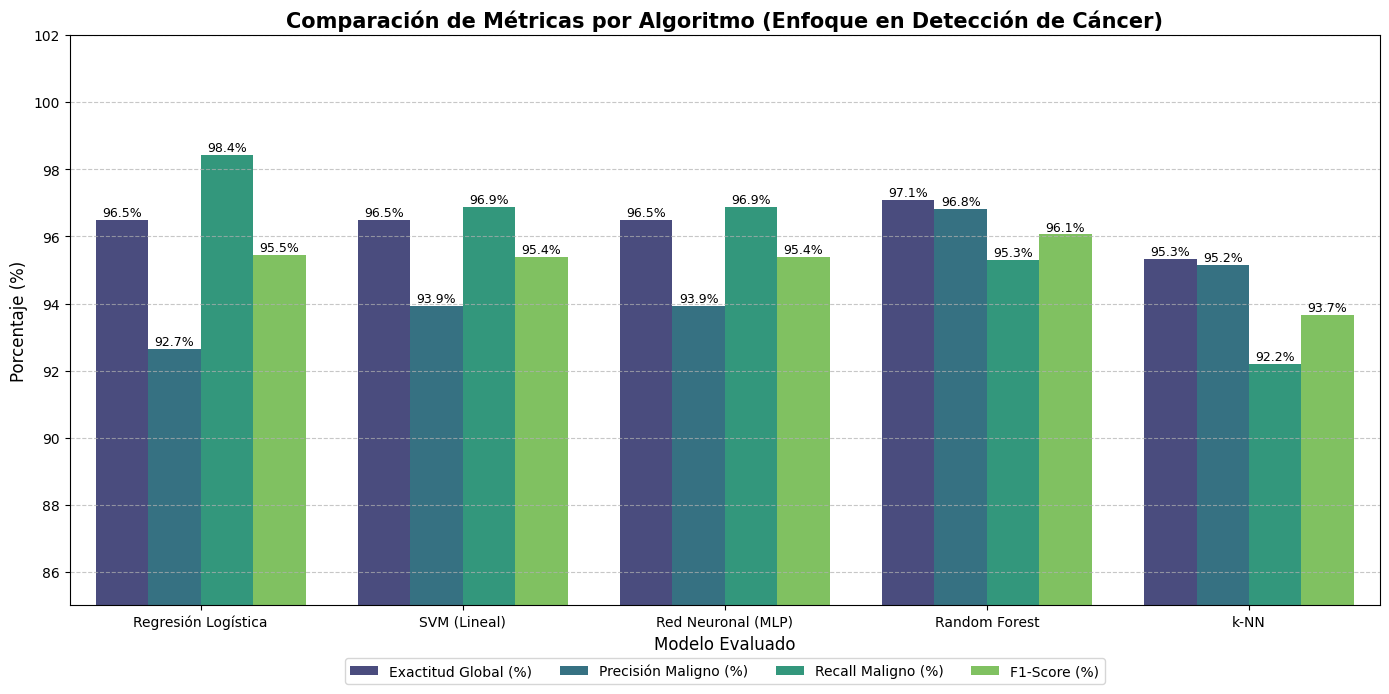

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from IPython.display import display

# 1. Agrupar los nombres y las predicciones de los 5 modelos
nombres_modelos = [
    'Regresión Logística', 
    'k-NN', 
    'SVM (Lineal)', 
    'Random Forest', 
    'Red Neuronal (MLP)'
]

predicciones = [
    y_pred_lr, 
    y_pred_knn, 
    y_pred_svm, 
    y_pred_rf, 
    y_pred_mlp
]

resultados = []

# 2. Calcular métricas automáticamente para cada modelo
for nombre, y_pred in zip(nombres_modelos, predicciones):
    acc = accuracy_score(y_test, y_pred)
    # pos_label=1 se enfoca en las métricas de la clase Maligna
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', pos_label=1)
    
    resultados.append({
        'Algoritmo': nombre,
        'Exactitud Global (%)': round(acc * 100, 2),
        'Precisión Maligno (%)': round(precision * 100, 2),
        'Recall Maligno (%)': round(recall * 100, 2),
        'F1-Score (%)': round(f1 * 100, 2)
    })

# 3. Crear y mostrar la tabla de resultados
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by='Recall Maligno (%)', ascending=False).reset_index(drop=True)

print("=== TABLA COMPARATIVA DE RENDIMIENTO ===")
display(df_resultados)

# 4. Generar gráfico comparativo
# Transformar datos para seaborn (Melt)
df_melt = df_resultados.melt(id_vars='Algoritmo', var_name='Métrica', value_name='Porcentaje')

plt.figure(figsize=(14, 7))
sns.barplot(x='Algoritmo', y='Porcentaje', hue='Métrica', data=df_melt, palette='viridis')

# Ajustar el gráfico para que las diferencias sean visibles (hacer zoom en la parte superior)
plt.ylim(85, 102) 
plt.title('Comparación de Métricas por Algoritmo (Enfoque en Detección de Cáncer)', fontsize=15, fontweight='bold')
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Modelo Evaluado', fontsize=12)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=4)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Agregar los valores encima de las barras
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f"{p.get_height():.1f}%", 
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                           textcoords='offset points')

plt.tight_layout()
plt.show()